# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import functions.data_helpers as data_helpers
import functions.model_helpers as model_helpers

In [ ]:
data_folder = "data/"

trainxs = np.load(os.path.join(data_folder, "fashion-train-imgs.npz"))
trainys = np.load(os.path.join(data_folder, "fashion-train-labels.npz"))
devxs = np.load(os.path.join(data_folder, "fashion-dev-imgs.npz"))
devys = np.load(os.path.join(data_folder, "fashion-dev-labels.npz"))
testxs = np.load(os.path.join(data_folder, "fashion-test-imgs.npz"))
testys = np.load(os.path.join(data_folder, "fashion-test-labels.npz"))

## Data exploration & preparation

Y Label: 0


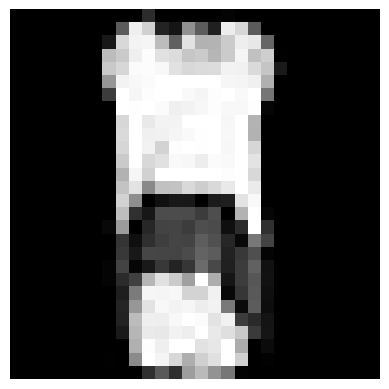

Y Label: 0


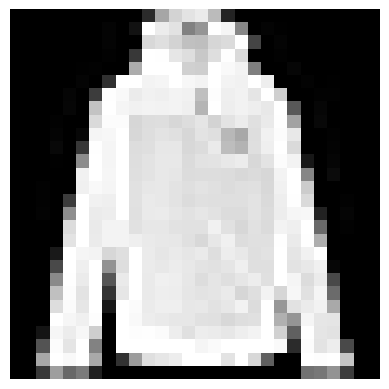

In [ ]:
# Display an example image with label

examples_to_show = list(range(40, 42))

data_helpers.display_examples(examples_to_show, trainxs, trainys)

In [4]:
# Reshape data (flatten images to 1D)

trainxs_flat = data_helpers.flatten_2d_images(trainxs)
devxs_flat = data_helpers.flatten_2d_images(devxs)
testxs_flat = data_helpers.flatten_2d_images(testxs)

print(f"Original train data shape: {trainxs.shape}")
print(f"Flattened train data shape: {trainxs_flat.shape}")
print(f"Original dev data shape: {devxs.shape}")
print(f"Flattened dev data shape: {devxs_flat.shape}")
print(f"Original test data shape: {testxs.shape}")
print(f"Flattened test data shape: {testxs_flat.shape}")

Original train data shape: (28, 28, 12000)
Flattened train data shape: (784, 12000)
Original dev data shape: (28, 28, 1000)
Flattened dev data shape: (784, 1000)
Original test data shape: (28, 28, 1000)
Flattened test data shape: (784, 1000)


## Useful Values

In [5]:
# Number of examples in each dataset
train_n = trainxs_flat.shape[1]
dev_n = devxs_flat.shape[1]
test_n = testxs_flat.shape[1]

# Number of dimesions in each image
dims = trainxs_flat.shape[0]

# Pixel value range
pixel_value_max = np.amax(trainxs_flat)
pixel_value_min = np.amin(trainxs_flat)
print(f"Max pixel value: {pixel_value_max}")
print(f"Min pixel value: {pixel_value_min}")

Max pixel value: 1.0
Min pixel value: 0.0


# Perceptron implementation

In [ ]:
NUMBER_OF_EPOCHS = 100
w = np.zeros(dims)
b = 0.0

train_accuracy_per_epoch = []
dev_accuracy_per_epoch = []

best_dev_accuracy = 0
best_dev_bias = 0
best_dev_weights = np.zeros(dims)

for j in range(NUMBER_OF_EPOCHS):
    train_errors = 0
    dev_errors = 0

    shuffled_indices = [*range(0, train_n, 1)]
    np.random.shuffle(shuffled_indices)

    # Run a training epoch
    for i in shuffled_indices:
        train_x = trainxs_flat[:, i]
        train_pred = 1 if (np.dot(w, train_x) + b) >= 0 else 0
        if train_pred == 0 and trainys[i] == 1:
            w += train_x
            b += 1
            train_errors += 1
        if train_pred == 1 and trainys[i] == 0:
            w -= train_x
            b -= 1
            train_errors += 1
    train_accuracy_per_epoch.append((train_n - train_errors) / train_n)

    # Evaluate the updated weights and bias on the validation set
    for i in range(dev_n):
        dev_x = devxs_flat[:, i]
        dev_pred = 1 if (np.dot(w, dev_x) + b) >= 0 else 0
        if dev_pred != devys[i]:
            dev_errors += 1
    dev_accuracy = (dev_n - dev_errors) / dev_n
    dev_accuracy_per_epoch.append(dev_accuracy)

    # Store accuracy, weights, and bias from epoch with best validation accuracy
    if dev_accuracy > best_dev_accuracy:
        best_dev_accuracy = dev_accuracy
        best_dev_weights = w
        best_dev_bias = b
        best_weights_epoch = j

    # Early stopping criteria
    if model_helpers.check_early_stopping(
        dev_accuracy_per_epoch, window_size=15, threshold=0.0, mode="max"
    ):
        print("Early stopping: Validation accuracy has not increased sufficiently.")
        break

# Accuracy on the training for the epoch on which we obtain the highest accuracy on the validation set

best_train_accuracy = train_accuracy_per_epoch[best_weights_epoch]

Early stopping: Validation accuracy has not increased sufficiently.


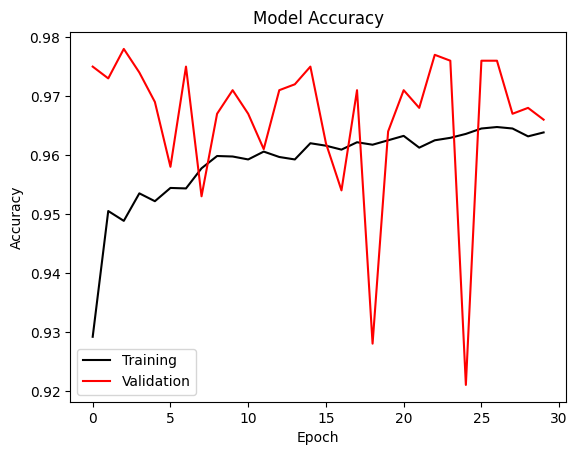

In [ ]:
data_helpers.plot_metrics(
    train_accuracy_per_epoch,
    dev_accuracy_per_epoch,
    title="Model Accuracy",
    ylabel="Accuracy",
    xlabel="Epoch",
    legend_labels=["Training", "Validation"],
    save_fig=False,
)

In [ ]:
# Final accuracy on test set

shuffled_indices = [*range(0, test_n, 1)]
np.random.shuffle(shuffled_indices)

test_errors = 0

for i in range(dev_n):
    test_x = testxs_flat[:, i]
    test_pred = 1 if (np.dot(w, test_x) + b) >= 0 else 0
    if test_pred != testys[i]:
        test_errors += 1
test_accuracy = (test_n - test_errors) / test_n
print("Test accuracy:", test_accuracy)

Test accuracy: 0.512


# MLP implementation





LEARNING RATE: 0.1
MOMENTUM: 0.9
BATCH SIZE: 32
Loss after iteration 0: 0.731626
Accuracy after iteration 0: 0.566333
Loss after iteration 100: 0.082384
Accuracy after iteration 100: 0.979583
Early stopping: Validation loss has not decreased sufficiently.


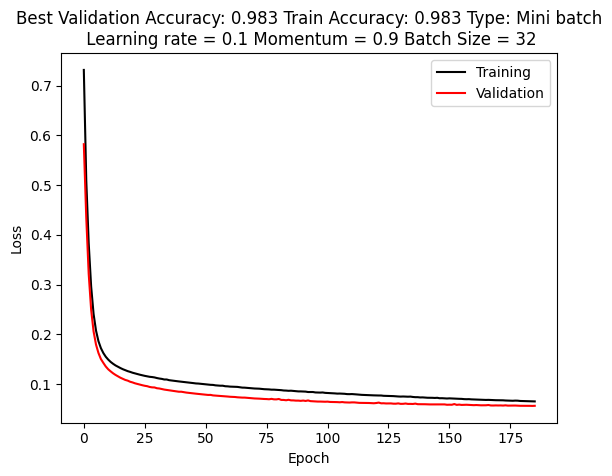

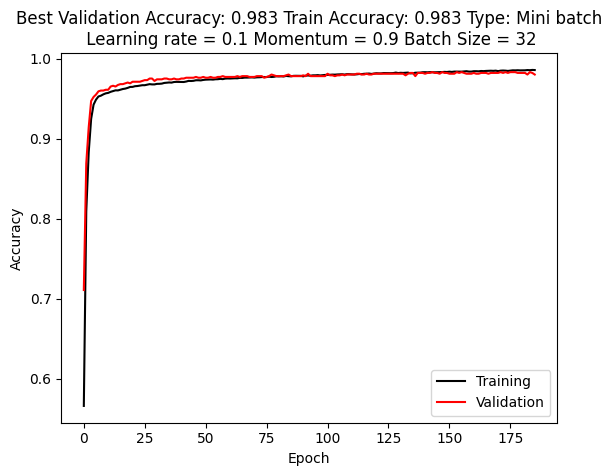

best_dev_accuracy: 0.983
train_accuracy: 0.9828333333333337
best_epoch: 143




LEARNING RATE: 0.1
MOMENTUM: 0.9
BATCH SIZE: 64
Loss after iteration 0: 0.770170
Accuracy after iteration 0: 0.506083
Loss after iteration 100: 0.099706
Accuracy after iteration 100: 0.972750
Loss after iteration 200: 0.083220
Accuracy after iteration 200: 0.979667
Early stopping: Validation loss has not decreased sufficiently.


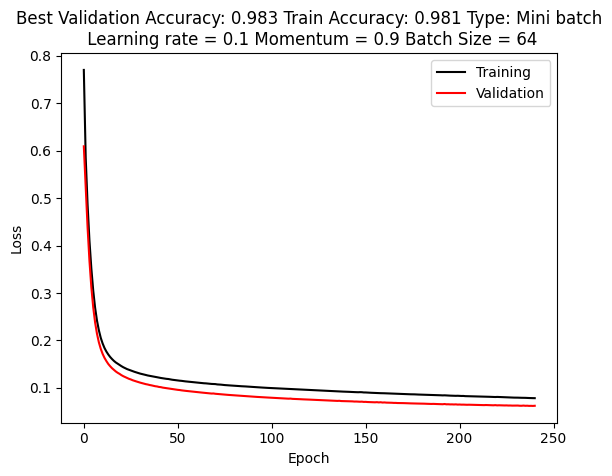

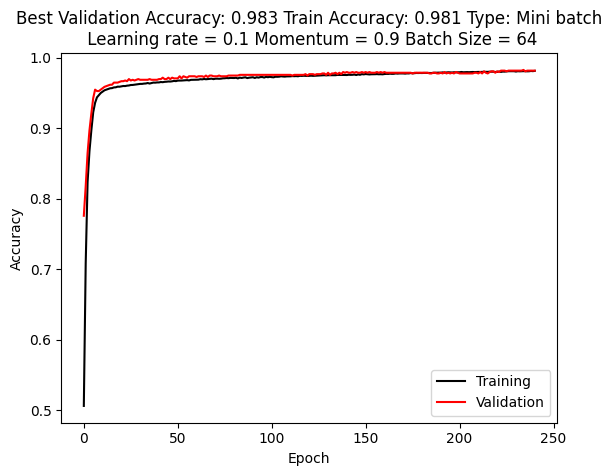

best_dev_accuracy: 0.983
train_accuracy: 0.9812500000000001
best_epoch: 234




LEARNING RATE: 0.1
MOMENTUM: 0.9
BATCH SIZE: 256
Loss after iteration 0: 0.846428
Accuracy after iteration 0: 0.500000
Loss after iteration 100: 0.140047
Accuracy after iteration 100: 0.960333
Loss after iteration 200: 0.117012
Accuracy after iteration 200: 0.966833
Loss after iteration 300: 0.106779
Accuracy after iteration 300: 0.970833
Early stopping: Validation loss has not decreased sufficiently.


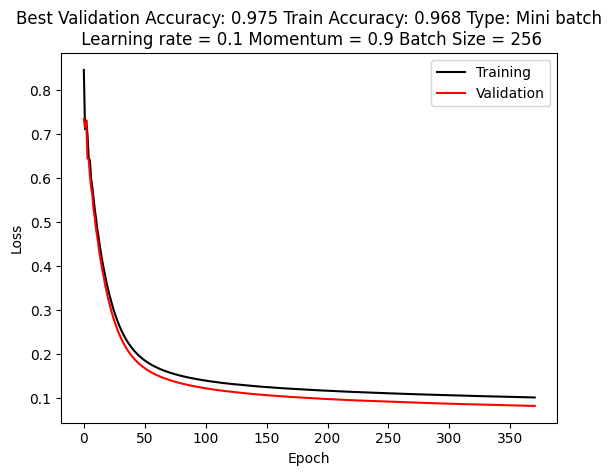

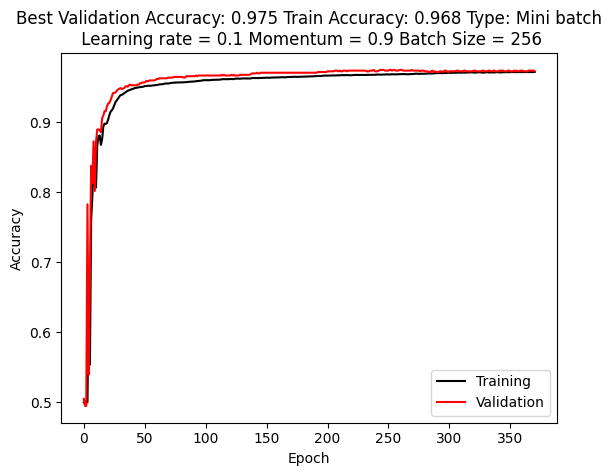

best_dev_accuracy: 0.975
train_accuracy: 0.9681666666666665
best_epoch: 238




LEARNING RATE: 0.1
MOMENTUM: 0.0
BATCH SIZE: 32
Loss after iteration 0: 0.654481
Accuracy after iteration 0: 0.668083
Loss after iteration 100: 0.143301
Accuracy after iteration 100: 0.960500
Loss after iteration 200: 0.119075
Accuracy after iteration 200: 0.966250
Loss after iteration 300: 0.108501
Accuracy after iteration 300: 0.970333
Early stopping: Validation loss has not decreased sufficiently.


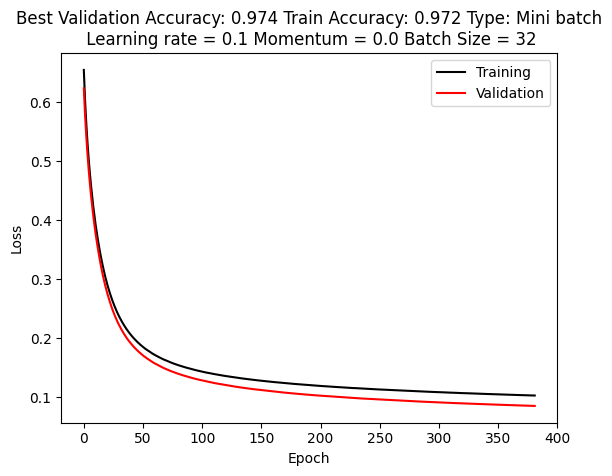

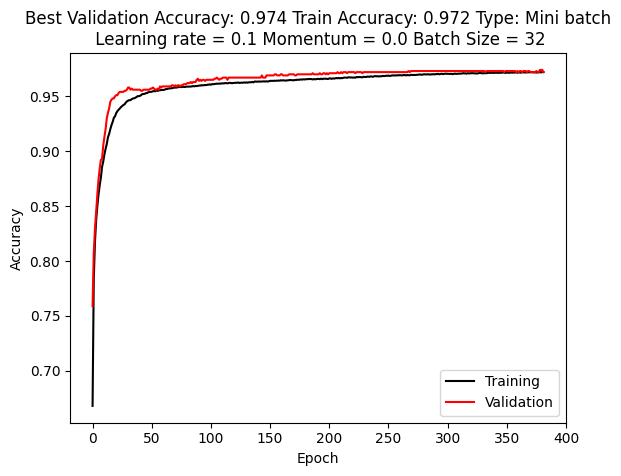

best_dev_accuracy: 0.974
train_accuracy: 0.9720833333333333
best_epoch: 378




LEARNING RATE: 0.1
MOMENTUM: 0.0
BATCH SIZE: 64
Loss after iteration 0: 0.664741
Accuracy after iteration 0: 0.670167
Loss after iteration 100: 0.195254
Accuracy after iteration 100: 0.953833
Loss after iteration 200: 0.145511
Accuracy after iteration 200: 0.961583
Loss after iteration 300: 0.128943
Accuracy after iteration 300: 0.963917
Loss after iteration 400: 0.119953
Accuracy after iteration 400: 0.966667
Early stopping: Validation loss has not decreased sufficiently.


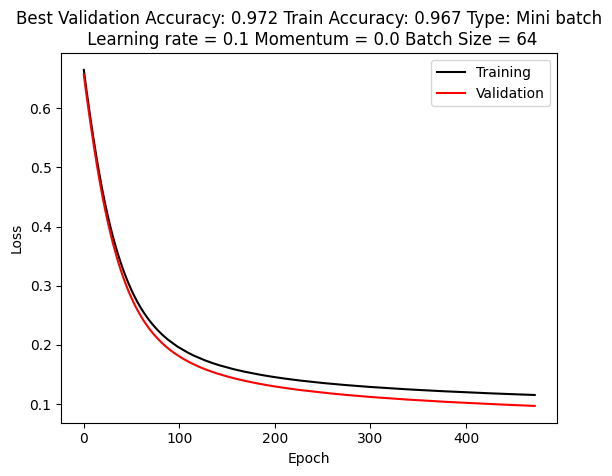

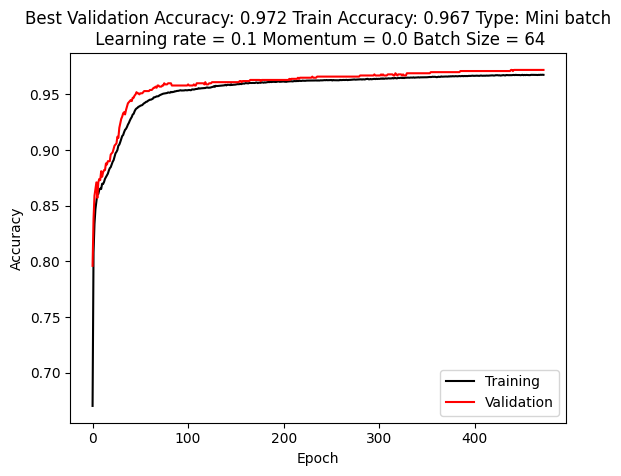

best_dev_accuracy: 0.972
train_accuracy: 0.9672499999999999
best_epoch: 438




LEARNING RATE: 0.1
MOMENTUM: 0.0
BATCH SIZE: 256
Loss after iteration 0: 0.689733
Accuracy after iteration 0: 0.525000
Loss after iteration 100: 0.432225
Accuracy after iteration 100: 0.886500
Loss after iteration 200: 0.304669
Accuracy after iteration 200: 0.930583
Loss after iteration 300: 0.238113
Accuracy after iteration 300: 0.945833
Loss after iteration 400: 0.202215
Accuracy after iteration 400: 0.951000
Loss after iteration 500: 0.180845
Accuracy after iteration 500: 0.953667
Loss after iteration 600: 0.166834
Accuracy after iteration 600: 0.956667
Loss after iteration 700: 0.156896
Accuracy after iteration 700: 0.958250
Loss after iteration 800: 0.149429
Accuracy after iteration 800: 0.959250
Early stopping: Validation loss has not decreased sufficiently.


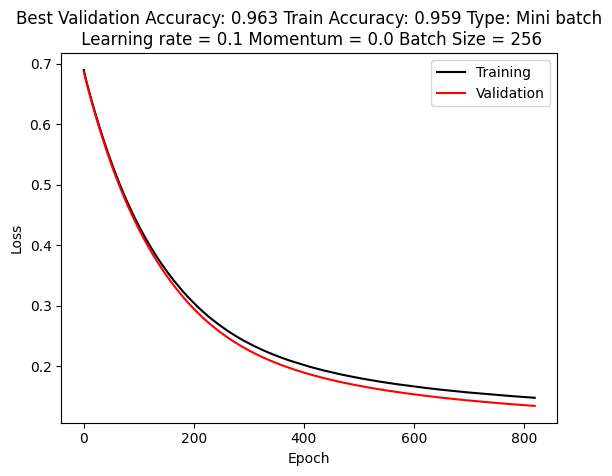

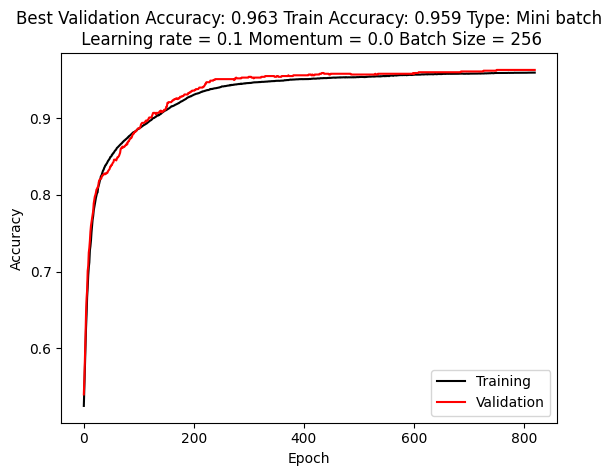

best_dev_accuracy: 0.963
train_accuracy: 0.959
best_epoch: 751




LEARNING RATE: 0.01
MOMENTUM: 0.9
BATCH SIZE: 32
Loss after iteration 0: 0.729312
Accuracy after iteration 0: 0.485250
Loss after iteration 100: 0.146329
Accuracy after iteration 100: 0.960167
Loss after iteration 200: 0.119887
Accuracy after iteration 200: 0.966500
Loss after iteration 300: 0.108658
Accuracy after iteration 300: 0.970333
Loss after iteration 400: 0.101557
Accuracy after iteration 400: 0.972583
Early stopping: Validation loss has not decreased sufficiently.


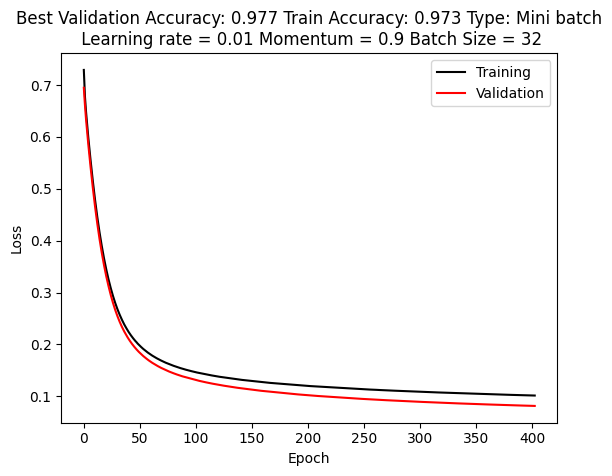

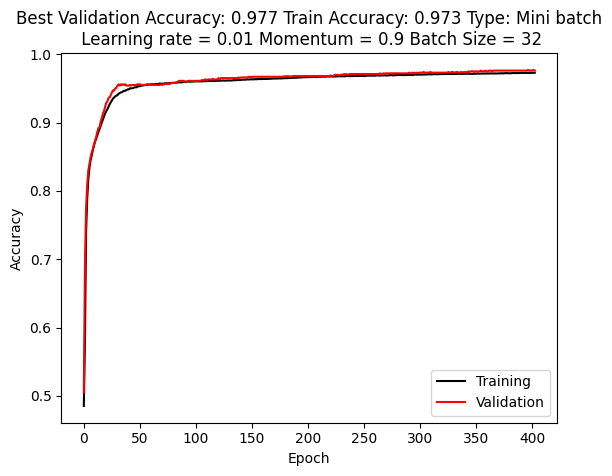

best_dev_accuracy: 0.977
train_accuracy: 0.9726666666666666
best_epoch: 396




LEARNING RATE: 0.01
MOMENTUM: 0.9
BATCH SIZE: 64
Loss after iteration 0: 0.703151
Accuracy after iteration 0: 0.504917
Loss after iteration 100: 0.196700
Accuracy after iteration 100: 0.952500
Loss after iteration 200: 0.147682
Accuracy after iteration 200: 0.958833
Loss after iteration 300: 0.131155
Accuracy after iteration 300: 0.962583
Loss after iteration 400: 0.122016
Accuracy after iteration 400: 0.965000
Early stopping: Validation loss has not decreased sufficiently.


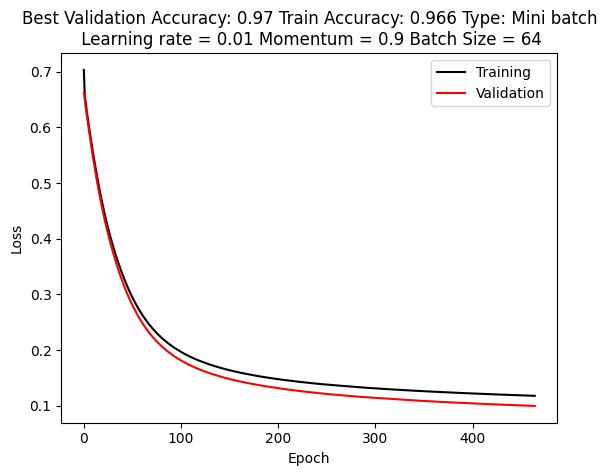

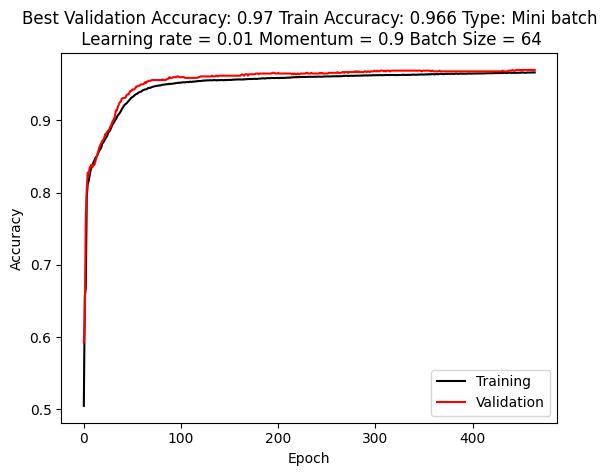

best_dev_accuracy: 0.97
train_accuracy: 0.9658333333333334
best_epoch: 441




LEARNING RATE: 0.01
MOMENTUM: 0.9
BATCH SIZE: 256
Loss after iteration 0: 0.729217
Accuracy after iteration 0: 0.500000
Loss after iteration 100: 0.506113
Accuracy after iteration 100: 0.856000
Loss after iteration 200: 0.357515
Accuracy after iteration 200: 0.910000
Loss after iteration 300: 0.268879
Accuracy after iteration 300: 0.939667
Loss after iteration 400: 0.220096
Accuracy after iteration 400: 0.947583
Loss after iteration 500: 0.192022
Accuracy after iteration 500: 0.952667
Loss after iteration 600: 0.174344
Accuracy after iteration 600: 0.954833
Loss after iteration 700: 0.162274
Accuracy after iteration 700: 0.957083
Loss after iteration 800: 0.153500
Accuracy after iteration 800: 0.958667
Early stopping: Validation loss has not decreased sufficiently.


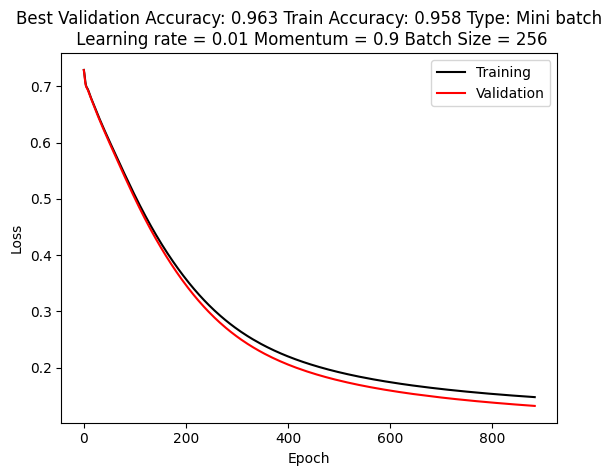

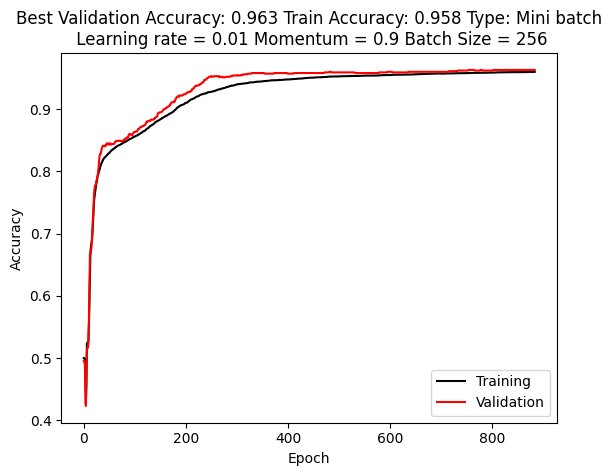

best_dev_accuracy: 0.963
train_accuracy: 0.9580000000000001
best_epoch: 753




LEARNING RATE: 0.01
MOMENTUM: 0.0
BATCH SIZE: 32
Loss after iteration 0: 0.701636
Accuracy after iteration 0: 0.498417
Loss after iteration 100: 0.484985
Accuracy after iteration 100: 0.866333
Loss after iteration 200: 0.354800
Accuracy after iteration 200: 0.914417
Loss after iteration 300: 0.276651
Accuracy after iteration 300: 0.940583
Loss after iteration 400: 0.230477
Accuracy after iteration 400: 0.948750
Loss after iteration 500: 0.202242
Accuracy after iteration 500: 0.952833
Loss after iteration 600: 0.183788
Accuracy after iteration 600: 0.954833
Loss after iteration 700: 0.170933
Accuracy after iteration 700: 0.956417
Loss after iteration 800: 0.161475
Accuracy after iteration 800: 0.957917
Loss after iteration 900: 0.154219
Accuracy after iteration 900: 0.958417
Early stopping: Validation loss has not decreased sufficiently.


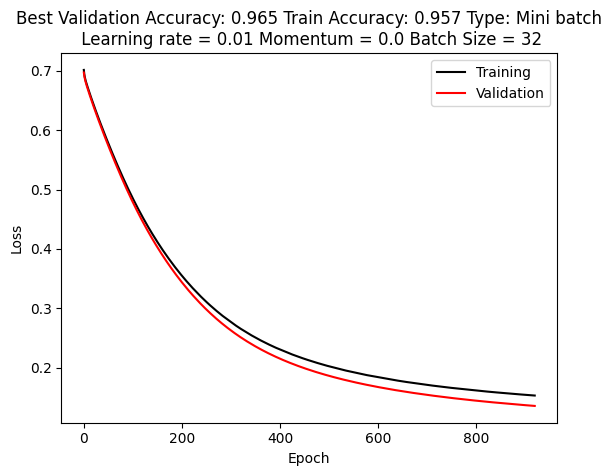

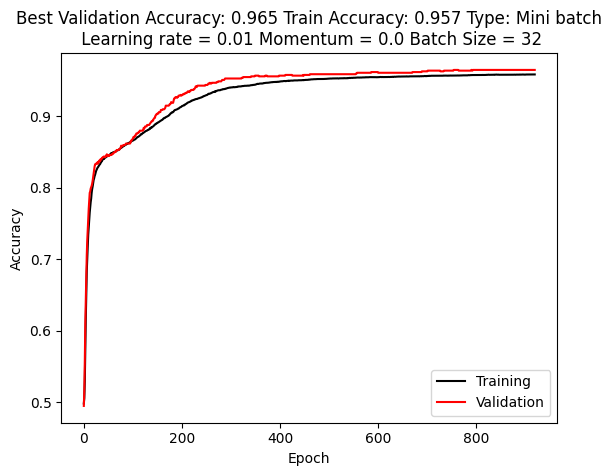

best_dev_accuracy: 0.965
train_accuracy: 0.9569999999999999
best_epoch: 754




LEARNING RATE: 0.01
MOMENTUM: 0.0
BATCH SIZE: 64
Loss after iteration 0: 0.934781
Accuracy after iteration 0: 0.500000
Loss after iteration 100: 0.531498
Accuracy after iteration 100: 0.867250
Loss after iteration 200: 0.425823
Accuracy after iteration 200: 0.896833
Loss after iteration 300: 0.355346
Accuracy after iteration 300: 0.920417
Loss after iteration 400: 0.305406
Accuracy after iteration 400: 0.938333
Loss after iteration 500: 0.269336
Accuracy after iteration 500: 0.944500
Loss after iteration 600: 0.242938
Accuracy after iteration 600: 0.948083
Loss after iteration 700: 0.223201
Accuracy after iteration 700: 0.950750
Loss after iteration 800: 0.208071
Accuracy after iteration 800: 0.952250
Loss after iteration 900: 0.196194
Accuracy after iteration 900: 0.953917
Loss after iteration 1000: 0.186660
Accuracy after iteration 1000: 0.955167
Loss after iteration 1100: 0.178858
Accuracy after iteratio

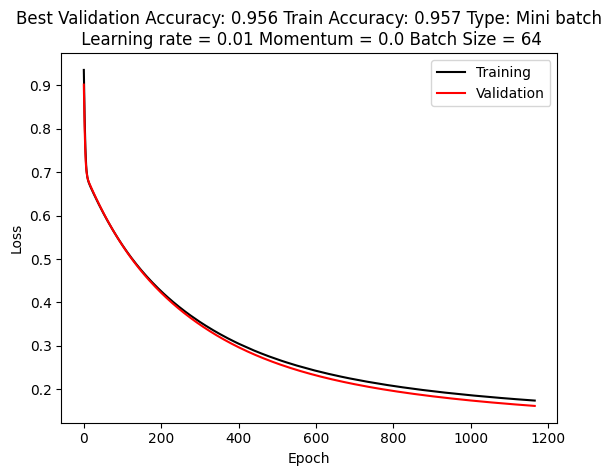

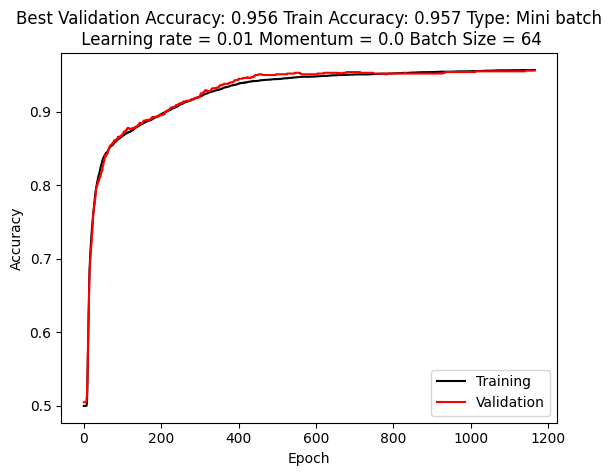

best_dev_accuracy: 0.956
train_accuracy: 0.9568333333333331
best_epoch: 1142




LEARNING RATE: 0.01
MOMENTUM: 0.0
BATCH SIZE: 256
Loss after iteration 0: 0.705883
Accuracy after iteration 0: 0.497417
Loss after iteration 100: 0.642963
Accuracy after iteration 100: 0.747000
Loss after iteration 200: 0.604484
Accuracy after iteration 200: 0.790583
Loss after iteration 300: 0.570396
Accuracy after iteration 300: 0.823333
Loss after iteration 400: 0.539795
Accuracy after iteration 400: 0.849333
Loss after iteration 500: 0.511917
Accuracy after iteration 500: 0.864417
Loss after iteration 600: 0.486324
Accuracy after iteration 600: 0.875167
Loss after iteration 700: 0.462764
Accuracy after iteration 700: 0.884667
Loss after iteration 800: 0.441060
Accuracy after iteration 800: 0.892333
Loss after iteration 900: 0.421068
Accuracy after iteration 900: 0.899667
Loss after iteration 1000: 0.402641
Accuracy after iteration 1000: 0.906250
Loss after iteration 1100: 0.385649
Accuracy after iterat

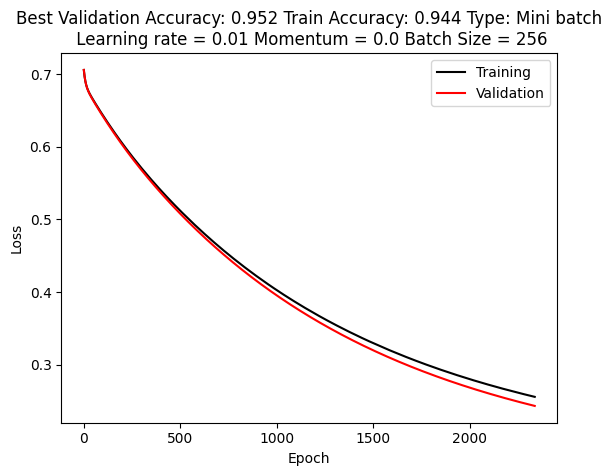

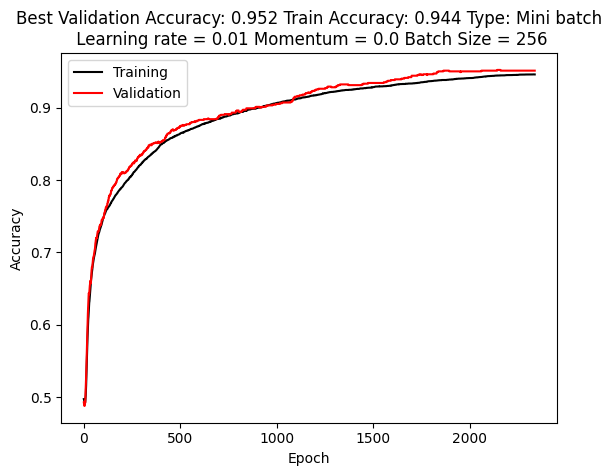

best_dev_accuracy: 0.952
train_accuracy: 0.9443333333333334
best_epoch: 2142


In [6]:
# Set dimensionality of each layer
layers_dims = [784, 100, 60, 1]

# Select hyperparameters using grid search
learning_rates = [0.1, 0.01]
batch_sizes = [32, 64, 256]
momentums = [0.9, 0.0]

stored_best_models = {}

# Loop through hyperparameters (grid search)
for i in range(len(learning_rates)):
    for j in range(len(momentums)):
        for b in range(len(batch_sizes)):
            rate = learning_rates[i]
            momentum = momentums[j]
            batch = batch_sizes[b]
            print("\n")
            print("\n")
            print(f"LEARNING RATE: {rate}")
            print(f"MOMENTUM: {momentum}")
            print(f"BATCH SIZE: {batch}")

            parameters, best_model, loss, dev_loss, accs, dev_accuracies, title = (
                model_helpers.three_layer_model(
                    X=trainxs_flat,
                    Y=trainys,
                    devxs=devxs_flat,
                    devys=devys,
                    layers_dims=layers_dims,
                    data_dims=dims,
                    learning_rate=rate,
                    max_epochs=5000,
                    momentum_coefficient=momentum,
                    batch_size=batch,
                )
            )

            data_helpers.plot_metrics(
                np.squeeze(loss),
                np.squeeze(dev_loss),
                title=title,
                ylabel="Loss",
                xlabel="Epoch",
                legend_labels=["Training", "Validation"],
                save_fig=False,
                line_colors=("k", "r"),
            )

            data_helpers.plot_metrics(
                np.squeeze(accs),
                np.squeeze(dev_accuracies),
                title=title,
                ylabel="Accuracy",
                xlabel="Epoch",
                legend_labels=["Training", "Validation"],
                save_fig=False,
                line_colors=("k", "r"),
            )

            stored_best_models[str(rate) + "-" + str(momentum) + "-" + str(batch)] = (
                best_model
            )

            # Print out results for epoch with best validation accuracy
            best_dev_accuracy, best_train_accuracy, best_epoch, best_dev_parameters = (
                best_model
            )
            print(f"best_dev_accuracy: {best_dev_accuracy}")
            print(f"train_accuracy: {best_train_accuracy}")
            print(f"best_epoch: {best_epoch}")